<h1 style="text-align:center;">
Retail Sales & Seasonal Trend Analysis using Python
</h1>

<h3 style="text-align:center; color: gray;">
Exploratory Data Analysis (EDA)
</h3>

<hr>

## Project Overview

Retail businesses generate large volumes of sales data every day. Analyzing this data helps organizations understand customer demand, product performance, and seasonal purchasing patterns.

This project focuses on analyzing retail sales data to identify key sales trends, seasonal patterns, and product performance. Using Python and data analysis libraries, we explore how sales vary across different months, suppliers, and product categories.

The goal of this analysis is to extract actionable insights that can help businesses improve inventory management, optimize product strategy, and prepare for seasonal demand fluctuations.

## Business Problem

Retail companies often struggle to identify patterns in their sales data due to the large volume of transactions generated daily.

Key business questions include:

• How do retail sales change across different months of the year?  
• Are there clear seasonal trends in product demand?  
• Which suppliers and products contribute the most to total sales?  
• What is the difference between retail sales and warehouse sales performance?

By analyzing historical retail sales data, businesses can better understand customer purchasing behavior and make data-driven decisions related to inventory planning, supplier management, and sales strategy.

## Project Objectives

The main objectives of this project are:

• Analyze overall retail sales performance  
• Identify monthly and seasonal sales trends  
• Evaluate product and supplier performance  
• Compare retail and warehouse sales contributions  
• Generate insights that support better business decisions

## Tools & Technologies Used

Python  
Pandas – Data analysis and manipulation  
NumPy – Numerical operations  
Matplotlib – Data visualization  
Seaborn – Statistical data visualization  
Jupyter Notebook – Project development environment

## Import Important Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Import Dataset

In [5]:
df = pd.read_csv("Retail & Warehouse Sales_Cleaned.csv")

df.head()

,YEAR,MONTH,SUPPLIER,ITEM_CODE,ITEM_DESCRIPTION,ITEM_TYPE,RETAIL_SALES,RETAIL_TRANSFERS,WAREHOUSE_SALES,TOTAL_SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,2.00
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,5.00
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,1.00
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,1.00
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,0.82


## Dataset Description

The dataset contains retail and warehouse sales transaction records. Each row represents a sales record for a specific product.

Key columns in the dataset include:

• Year – Year of transaction  
• Month – Month of transaction  
• Supplier – Product supplier  
• Item Description – Product name  
• Item Type – Product category  
• Retail Sales – Sales made through retail channels  
• Retail Transfers – Product transfers between retail locations  
• Warehouse Sales – Sales from warehouse distribution  
• Total Sales – Combined sales value

This dataset allows us to analyze sales patterns across time, suppliers, and product categories.

## Dataset Overview

### Dataset Shape

In [33]:
print("Dataset Shape:", df.shape)

Dataset Shape: (30000, 11)


### Dataset Information

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              30000 non-null  int64  
 1   MONTH             30000 non-null  int64  
 2   SUPPLIER          30000 non-null  object 
 3   ITEM_CODE         30000 non-null  object 
 4   ITEM_DESCRIPTION  30000 non-null  object 
 5   ITEM_TYPE         30000 non-null  object 
 6   RETAIL_SALES      30000 non-null  float64
 7   RETAIL_TRANSFERS  30000 non-null  float64
 8   WAREHOUSE_SALES   30000 non-null  float64
 9   TOTAL_SALES       30000 non-null  float64
 10  Quarter           30000 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 2.5+ MB


### Statistical Summary

In [8]:
df.describe()

,YEAR,MONTH,RETAIL_SALES,RETAIL_TRANSFERS,WAREHOUSE_SALES,TOTAL_SALES
count,30000.0,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2020.0,3.911467,6.939565,6.594058,27.431031,40.964654
std,0.0,2.836788,33.080527,27.879428,272.166085,307.499493
min,2020.0,1.000000,-0.420000,-6.000000,-3999.000000,-3999.000000
25%,2020.0,1.000000,0.000000,0.000000,0.000000,1.000000
50%,2020.0,3.000000,0.160000,0.000000,1.000000,3.000000
75%,2020.0,7.000000,2.920000,3.000000,6.000000,15.000000
max,2020.0,9.000000,2739.000000,1507.000000,18317.000000,20532.000000


The statistical summary provides key metrics such as mean, minimum, maximum, and standard deviation for numerical columns, helping understand sales distribution.

## Check Data Quality

In [9]:
df.isnull().sum()

YEAR                0
MONTH               0
SUPPLIER            0
ITEM_CODE           0
ITEM_DESCRIPTION    0
ITEM_TYPE           0
RETAIL_SALES        0
RETAIL_TRANSFERS    0
WAREHOUSE_SALES     0
TOTAL_SALES         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

To better analyze seasonal sales patterns, additional features were created from the existing dataset.

For example, a new **Quarter** column was generated using the month column. This helps analyze sales performance across quarterly periods and detect seasonal demand changes.

Feature engineering improves the ability to analyze time-based patterns in sales data.

## Feature Engineering

In [12]:
df['Quarter'] = (df['MONTH'] - 1) // 3 + 1

In [13]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM_CODE,ITEM_DESCRIPTION,ITEM_TYPE,RETAIL_SALES,RETAIL_TRANSFERS,WAREHOUSE_SALES,TOTAL_SALES,Quarter
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,2.00,1
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,5.00,1
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,1.00,1
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,1.00,1
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,0.82,1


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to examine retail sales performance, identify seasonal patterns, and understand product and supplier contributions to overall sales.

The analysis focuses on the following key areas:

- Monthly sales trends to identify seasonal demand patterns  
- Sales distribution across different product categories (Item Types)  
- Supplier contribution to total sales revenue  
- Comparison between retail sales and warehouse sales performance  
- Quarterly sales trends to analyze seasonal business cycles
- Heatmap — Sales by Month and Item Type

## Exploratory Data Analysis

## Monthly Sales Trend

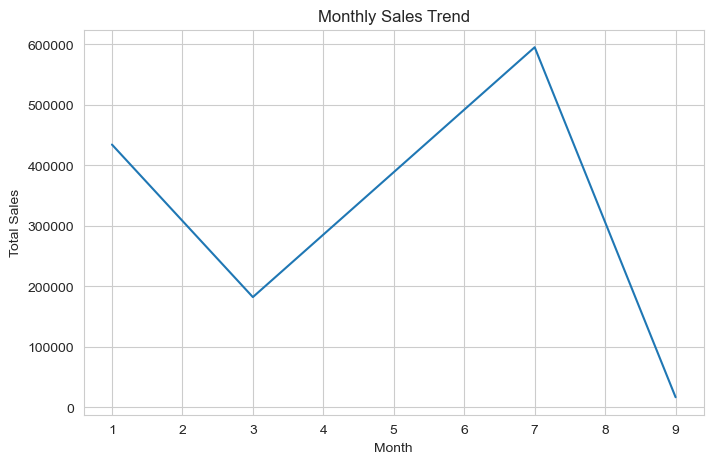

In [14]:
monthly_sales = df.groupby('MONTH')['TOTAL_SALES'].sum()

plt.figure(figsize=(8,5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

## Sales by Item Type

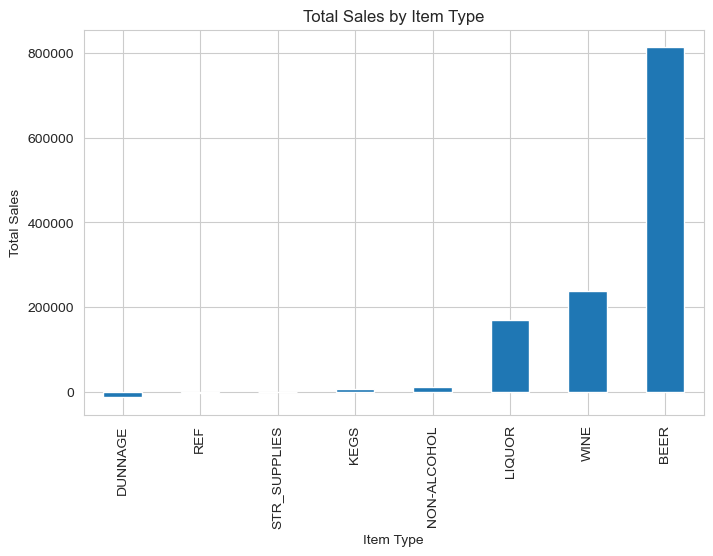

In [15]:
item_sales = df.groupby('ITEM_TYPE')['TOTAL_SALES'].sum().sort_values()

plt.figure(figsize=(8,5))

item_sales.plot(kind='bar')

plt.title("Total Sales by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Total Sales")

plt.show()

## Top 10 Suppliers by Sales

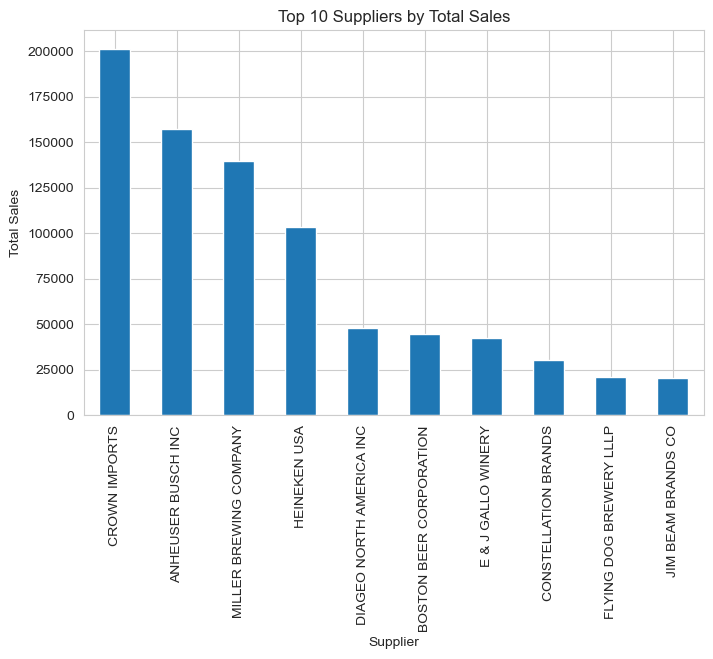

In [16]:
top_suppliers = df.groupby('SUPPLIER')['TOTAL_SALES'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

top_suppliers.plot(kind='bar')

plt.title("Top 10 Suppliers by Total Sales")
plt.xlabel("Supplier")
plt.ylabel("Total Sales")

plt.show()

## Retail vs Warehouse Sales Comparison

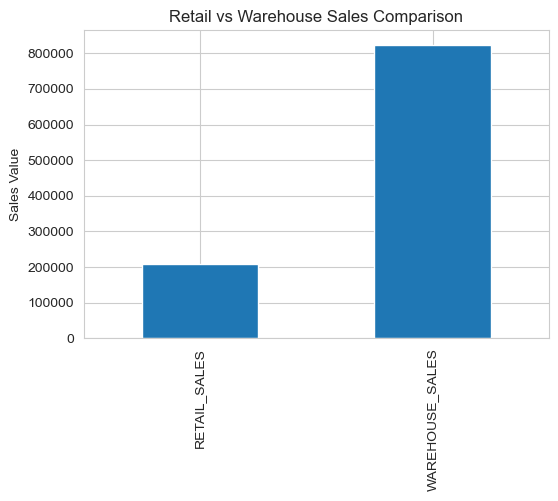

In [17]:
sales_channels = df[['RETAIL_SALES','WAREHOUSE_SALES']].sum()

plt.figure(figsize=(6,4))

sales_channels.plot(kind='bar')

plt.title("Retail vs Warehouse Sales Comparison")
plt.ylabel("Sales Value")

plt.show()

## Quarterly Sales Trend

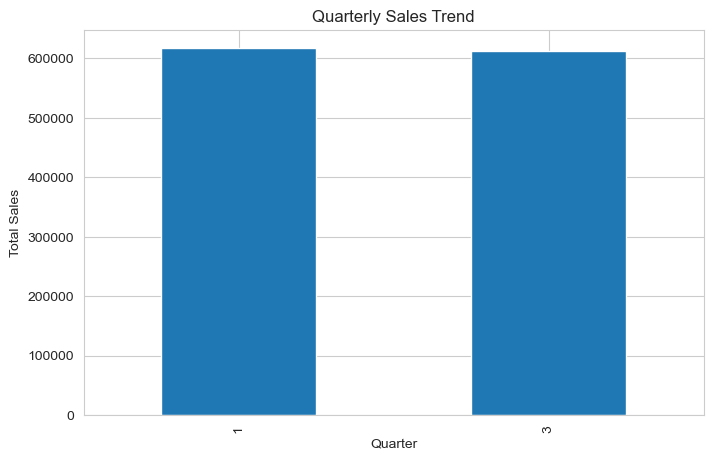

In [25]:
quarter_sales = df.groupby('Quarter')['TOTAL_SALES'].sum()

plt.figure(figsize=(8,5))

quarter_sales.plot(kind='bar')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.show()

## Heatmap — Sales by Month and Item Type

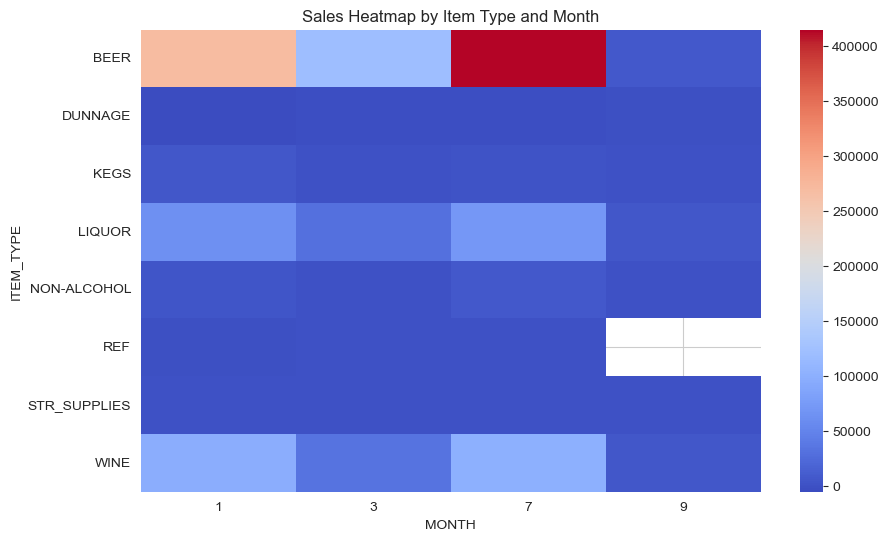

In [20]:
pivot_table = df.pivot_table(values='TOTAL_SALES', index='ITEM_TYPE', columns='MONTH', aggfunc='sum')

plt.figure(figsize=(10,6))

sns.heatmap(pivot_table, cmap='coolwarm')

plt.title("Sales Heatmap by Item Type and Month")

plt.show()

### Insight

The heatmap highlights variations in sales across different months and product categories, helping identify seasonal demand patterns for specific product types.

## Business Questions & Analysis

## Q1 What is the total retail sales revenue?

In [23]:
total_sales = df['TOTAL_SALES'].sum()

print(round(total_sales,2))

1228939.61


## Q2 How do sales vary across different months?

MONTH
1    434430.84
3    182334.20
7    595339.95
9     16834.62
Name: TOTAL_SALES, dtype: float64


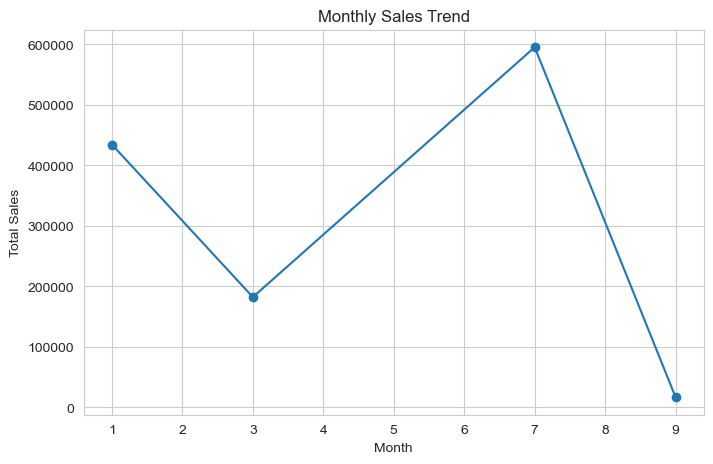

In [24]:
monthly_sales = df.groupby('MONTH')['TOTAL_SALES'].sum()

print(round(monthly_sales,2))

plt.figure(figsize=(8,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

### Insight

The monthly sales trend shows fluctuations throughout the year, indicating seasonal demand patterns. 
Some months generate higher sales compared to others, suggesting that customer purchasing behavior varies across different periods of the year.

## Q3 Which month has the Highest Sales?

In [27]:
highest_sales_month = df.groupby('MONTH')['TOTAL_SALES'].sum().idxmax()

print("Month with Highest Sales:", highest_sales_month)

Month with Highest Sales: 7


## Q4 Which product categories generate the most revenue?

ITEM_TYPE
BEER            812548.27
DUNNAGE         -12115.00
KEGS              8400.00
LIQUOR          170139.45
NON-ALCOHOL      12197.12
REF              -1248.73
STR_SUPPLIES      1240.60
WINE            237777.90
Name: TOTAL_SALES, dtype: float64


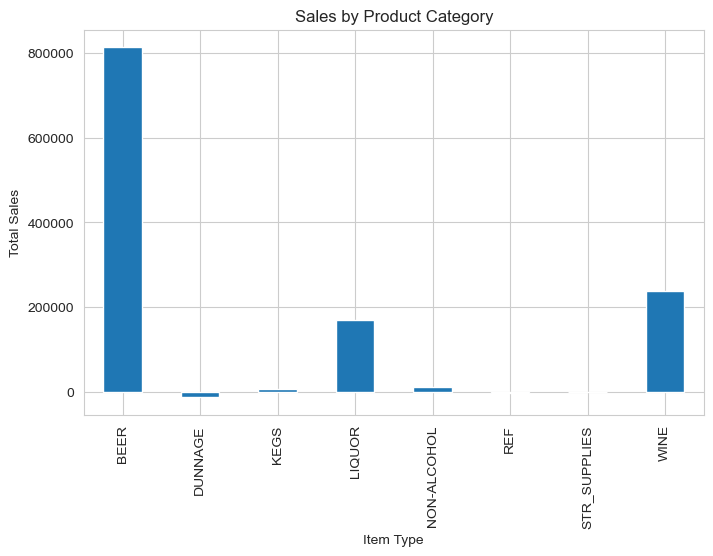

In [28]:
category_sales = df.groupby('ITEM_TYPE')['TOTAL_SALES'].sum()

print(round(category_sales,2))

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Product Category")
plt.xlabel("Item Type")
plt.ylabel("Total Sales")

plt.show()

### Insight

The analysis shows that **Beer generates the highest revenue among all product categories**.  
This indicates strong customer demand for beer products and highlights it as a key revenue driver for the business.

## Q5 Who are the top 10 suppliers by total sales?

SUPPLIER
CROWN IMPORTS               201333.62
ANHEUSER BUSCH INC          156974.66
MILLER BREWING COMPANY      139906.08
HEINEKEN USA                103198.20
DIAGEO NORTH AMERICA INC     47893.88
BOSTON BEER CORPORATION      44506.03
E & J GALLO WINERY           42446.65
CONSTELLATION BRANDS         30592.61
FLYING DOG BREWERY LLLP      21040.00
JIM BEAM BRANDS CO           20243.74
Name: TOTAL_SALES, dtype: float64


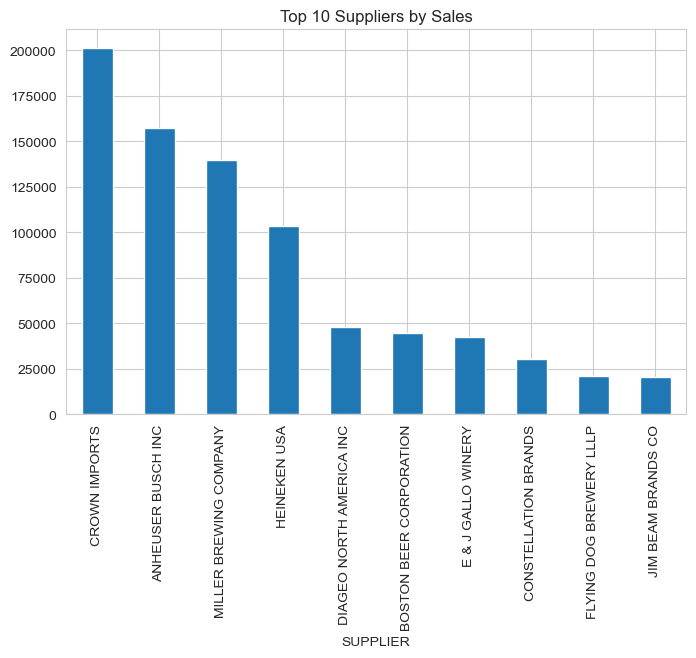

In [29]:
top_suppliers = df.groupby('SUPPLIER')['TOTAL_SALES'].sum().sort_values(ascending=False).head(10)

print(round(top_suppliers,2))

plt.figure(figsize=(8,5))

top_suppliers.plot(kind='bar')

plt.title("Top 10 Suppliers by Sales")

plt.show()

### Insight

The analysis shows that a small number of suppliers contribute significantly to total sales.  
These top suppliers play a crucial role in driving business revenue and maintaining product availability.

## Q6 What is the contribution of retail sales vs warehouse sales?

RETAIL_SALES       208186.94
WAREHOUSE_SALES    822930.93
dtype: float64


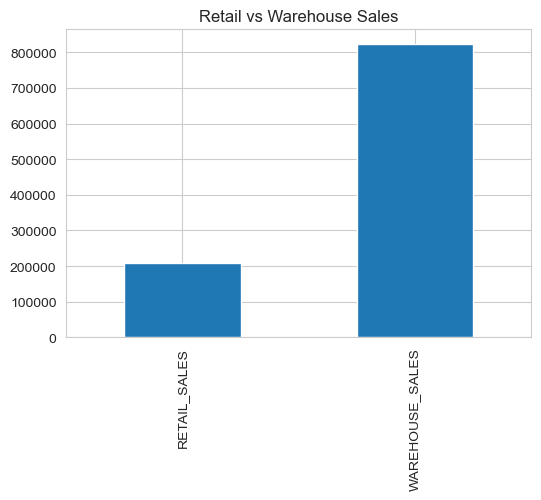

In [30]:
sales_channels = df[['RETAIL_SALES','WAREHOUSE_SALES']].sum()

print(round(sales_channels,2))

plt.figure(figsize=(6,4))

sales_channels.plot(kind='bar')

plt.title("Retail vs Warehouse Sales")

plt.show()

### Insight

The comparison between retail and warehouse sales highlights how revenue is distributed across different sales channels.  
Understanding this distribution helps businesses evaluate which channel performs better and where operational focus should be increased.

## Q7 How do sales vary across different quarters?

Quarter
1    616765.04
3    612174.57
Name: TOTAL_SALES, dtype: float64


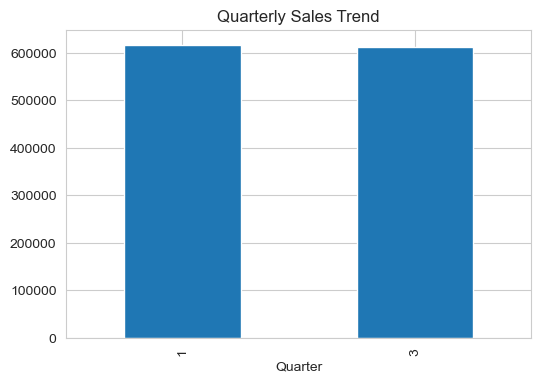

In [31]:
quarter_sales = df.groupby('Quarter')['TOTAL_SALES'].sum()

print(round(quarter_sales,2))

plt.figure(figsize=(6,4))

quarter_sales.plot(kind='bar')

plt.title("Quarterly Sales Trend")

plt.show()

### Insight

Quarterly analysis reveals seasonal fluctuations in sales performance throughout the year.  
Certain quarters generate higher revenue, indicating seasonal demand patterns that businesses can use for inventory planning and marketing strategies.

## Q8 What are the top 10 products by total sales?

In [32]:
top_products = df.groupby('ITEM_DESCRIPTION')['TOTAL_SALES'].sum().sort_values(ascending=False).head(10)

print(round(top_products,2))

ITEM_DESCRIPTION
CORONA EXTRA LOOSE NR - 12OZ            49109.50
HEINEKEN LOOSE NR - 12OZ                26792.88
CORONA EXTRA 2/12 NR - 12OZ             21082.50
MODELO ESPECIAL 24 LOOSE NR - 12OZ      20970.00
HEINEKEN 2/12 NR - 12OZ                 15936.40
MILLER LITE 30PK CAN - 12OZ             13459.40
MODELO ESPECIAL SUITCASE CANS - 12OZ    13092.84
CORONA EXTRA 18PK NR - 12OZ             10973.72
CORONA EXTRA 4/6 NR - 12OZ              10380.04
BUD LIGHT 30PK CAN                      10362.97
Name: TOTAL_SALES, dtype: float64


## Key Insights

• Sales show noticeable seasonal patterns, with certain months generating significantly higher revenue than others.

• A few key suppliers contribute a large portion of total sales, indicating strong dependence on specific supplier relationships.

• Beer and other high-demand product categories generate the highest share of revenue, making them important drivers of overall business performance.

• Retail sales contribute a larger share of revenue compared to warehouse sales, highlighting the importance of direct consumer purchases.

• Quarterly analysis reveals fluctuations in sales performance, suggesting that seasonal demand influences purchasing behavior throughout the year.

## Conclusion

This project analyzed retail sales data to identify seasonal sales patterns, supplier contributions, and product category performance using Python.

The analysis revealed clear variations in sales across months and quarters, indicating the presence of seasonal demand trends. Certain product categories and suppliers were found to contribute significantly to overall revenue.

These insights can help businesses improve inventory planning, strengthen supplier relationships, and prepare for seasonal demand fluctuations. By understanding sales patterns, companies can make more informed business decisions and optimize their sales strategies.

## Business Recommendation

• Increase inventory for high-demand product categories during peak months.  
• Strengthen partnerships with top-performing suppliers.  
• Focus marketing campaigns during high seasonal demand periods.  
• Optimize warehouse distribution for high-volume products.